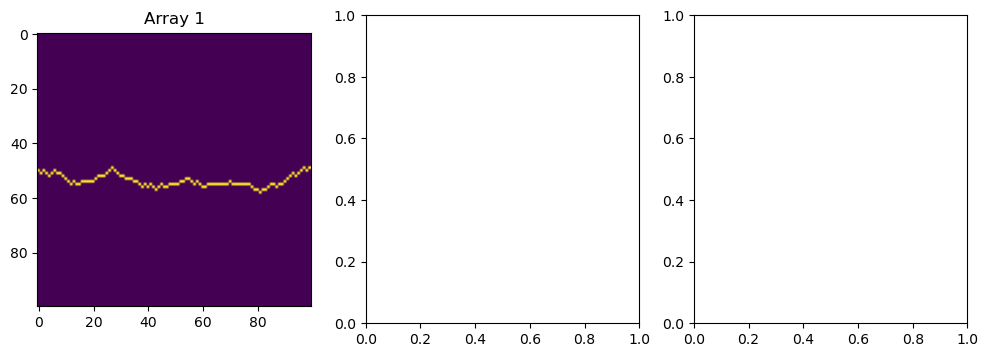

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def create_connected_boundary(shape, seed=None):
    if seed is not None:
        np.random.seed(seed)
    
    boundary = np.zeros(shape, dtype=np.uint8)
    
    # Generate a random walk for a connected boundary
    x, y = shape[0] // 2, 0  # Start from the left middle
    for i in range(shape[1]):
        boundary[x, y] = 1
        move = np.random.choice([-1, 0, 1])  # Move up, stay, or move down
        x = np.clip(x + move, 0, shape[0] - 1)
        y += 1  # Always move right
    
    return boundary.astype(bool)

def merge_arrays_with_boundary(array1, array2, boundary):
    merged_array = np.where(boundary, array1, array2)
    return merged_array

# Example usage
shape = (100, 100)
array1 = np.random.rand(*shape)
array2 = np.random.rand(*shape)

boundary = create_connected_boundary(shape, seed=42)

# Plot the arrays
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(boundary, cmap='viridis')
ax[0].set_title("Array 1")
plt.show()



In [41]:
image_sizes = [256, 512, 1024, 2048]
dtypes = [np.float32, np.float64]

gb = 1073741824 # bytes
num_imgs = 1e6

dd = np.array([size * size * dtype().nbytes for dtype in dtypes for size in image_sizes]) / gb  * num_imgs

y1 = dd[0:4]
y2 = dd[4:]

Text(0, 0.5, 'dataset size (GB)')

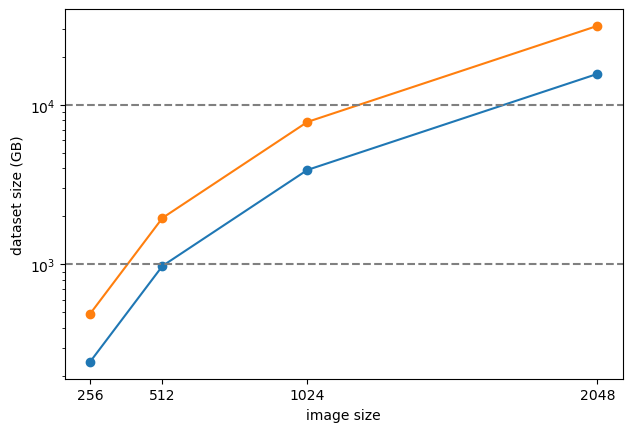

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(7.2, 4.8))
ax.plot(image_sizes, y1, marker='o')
ax.plot(image_sizes, y2, marker='o')

ax.axhline(1000, color='gray', ls='--')
ax.axhline(10000, color='gray', ls='--')

ax.set_yscale('log')
ax.set_xticks(image_sizes)
ax.set_xlabel('image size')
ax.set_ylabel('dataset size (GB)')